# DCGAN image generation

A deep convolutional GAN that learns to generate MNIST digits from random noise. This notebook trains the generator and discriminator together, tracks their losses, and shows how the generated samples sharpen over training. To keep the notebook fast it trains for a modest number of epochs on a subset; `scripts/train.py` runs a longer schedule.

In [1]:
import matplotlib.pyplot as plt

from dcgan.data import image_loaders
from dcgan.train import GANTrainer, sample_grid, set_seed

set_seed(0)

## Load data and train

MNIST downloads through torchvision on first use. Images are scaled to [-1, 1] to match the generator's Tanh output.

In [2]:
loader = image_loaders('mnist', root='../data', subset=10000)
trainer = GANTrainer()
fixed_noise = trainer.generator.sample_noise(64)
trainer.fit(loader, epochs=12, sample_every=4, fixed_noise=fixed_noise)

epoch   1  loss_d=0.6649  loss_g=2.1382


epoch   2  loss_d=0.6195  loss_g=1.7974


epoch   3  loss_d=0.6651  loss_g=1.6265


epoch   4  loss_d=0.6080  loss_g=1.6259


epoch   5  loss_d=0.6134  loss_g=1.6719


...

epoch   9  loss_d=0.4509  loss_g=2.0869


epoch  10  loss_d=0.4026  loss_g=2.1186


epoch  11  loss_d=0.7930  loss_g=2.0941


epoch  12  loss_d=0.5652  loss_g=1.8069


GANTrainer(nz=100, lr=0.0002, beta1=0.5, device='cpu', generator=Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): Tanh()
  )
), discriminator=Discriminator(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=

## Generated samples

Sixty-four digits generated from a fixed batch of noise after training.

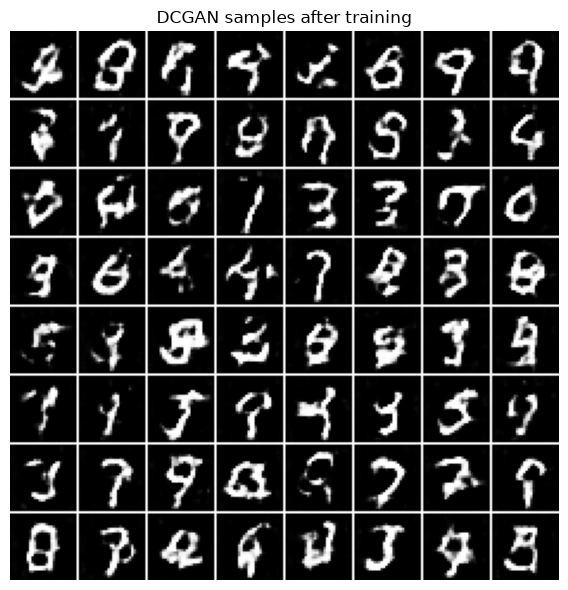

In [3]:
grid = sample_grid(trainer.generator, fixed_noise, nrow=8)
plt.figure(figsize=(6, 6))
plt.imshow(grid, cmap='gray')
plt.axis('off')
plt.title('DCGAN samples after training')
plt.tight_layout()
plt.show()

## Progression across training

The same noise decoded at several epochs, showing the generator move from noise toward digit-like shapes.

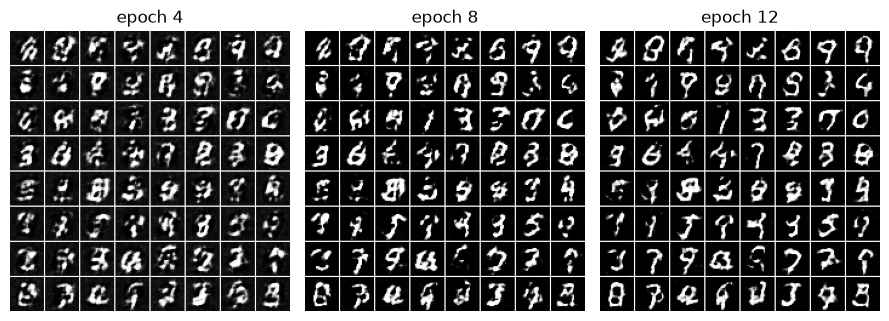

In [4]:
k = len(trainer.samples)
fig, axes = plt.subplots(1, k, figsize=(3 * k, 3.2))
if k == 1:
    axes = [axes]
for ax, (ep, g) in zip(axes, trainer.samples):
    ax.imshow(g, cmap='gray')
    ax.set_title(f'epoch {ep}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Training losses

In a healthy GAN the two losses stay in a rough equilibrium rather than one collapsing to zero.

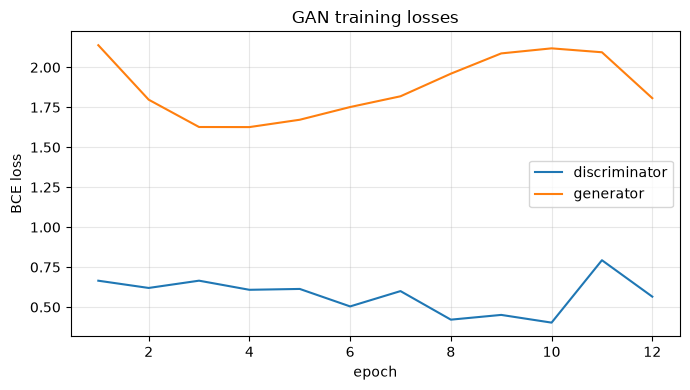

In [5]:
ep = range(1, len(trainer.history['loss_g']) + 1)
plt.figure(figsize=(7, 4))
plt.plot(ep, trainer.history['loss_d'], label='discriminator')
plt.plot(ep, trainer.history['loss_g'], label='generator')
plt.xlabel('epoch')
plt.ylabel('BCE loss')
plt.title('GAN training losses')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()